In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy.optimize import curve_fit
%matplotlib inline

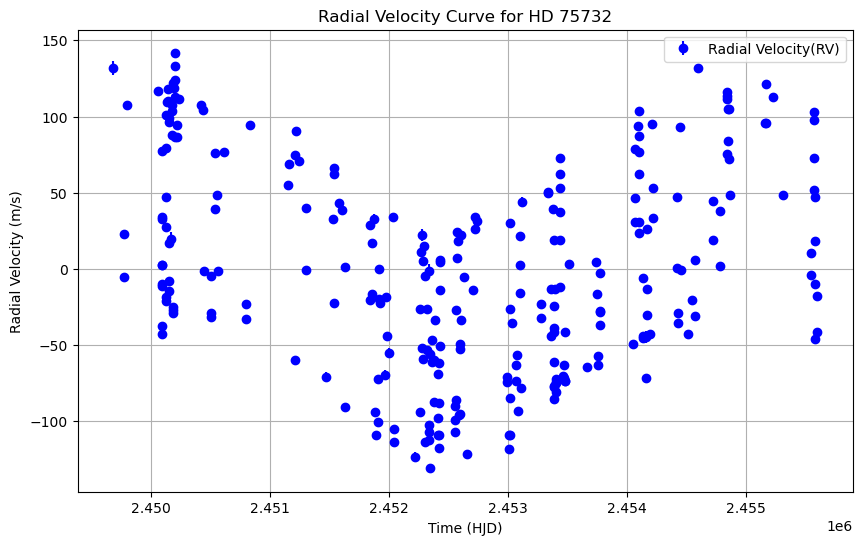

In [6]:
data = np.loadtxt('Radial.txt', skiprows=22)
# extracting data into variables time, rv, and uncertainty
time = data[:, 0]
rv = data[:, 1]
uncertainty = data[:,2]
# Creating plot
plt.figure(figsize=(10,6))
plt.errorbar(time,rv,yerr=uncertainty,fmt='o', color='blue', label='Radial Velocity(RV)')
plt.xlabel('Time (HJD)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity Curve for HD 75732')
plt.grid(True)
plt.legend()
plt.savefig('radial_velocity_curve.pdf', format='pdf')
plt.show()

Fitted parameters: A=47.91772823938166, B=0.0013070756559270414, C=-863.8021863524149, D=-1.4181871174045806


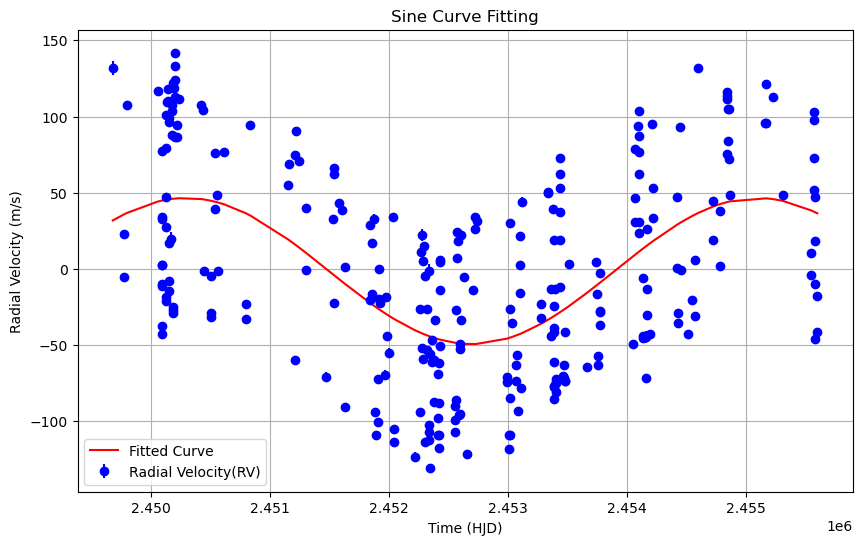

In [7]:
def sine_function(x, A, B, C, D):
    return A * np.sin(B * x + C) + D
initial = [140,0.000954,2.4525,0]
params, cov = curve_fit(sine_function, time, rv, sigma=uncertainty, absolute_sigma=True,p0=initial)
A_fit, B_fit, C_fit, D_fit = params
print(f"Fitted parameters: A={A_fit}, B={B_fit}, C={C_fit}, D={D_fit}")

# Generating my y values using the fitted parameters this time
y_fit = sine_function(time, A_fit, B_fit, C_fit, D_fit)
#back to plotting
plt.figure(figsize=(10,6))
plt.errorbar(time,rv,yerr=uncertainty,fmt='o', color='blue', label='Radial Velocity(RV)')
plt.plot(time, y_fit, label='Fitted Curve', color='red')
plt.xlabel('Time (HJD)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity Curve for HD 75732')
plt.grid(True)
plt.legend()
plt.title('Sine Curve Fitting')
#Saving my  plot as a pdf here
plt.savefig('sine_curve_fitting.pdf', format='pdf')
plt.show()

Error was in fitted parameters.  I had tried to restrict my parameters too much which caused my code to freak out. I rewrote my code completely using A through D_fit as my parameters instead which allowed me to use my data points instead of just guessing and hoping for the best. 

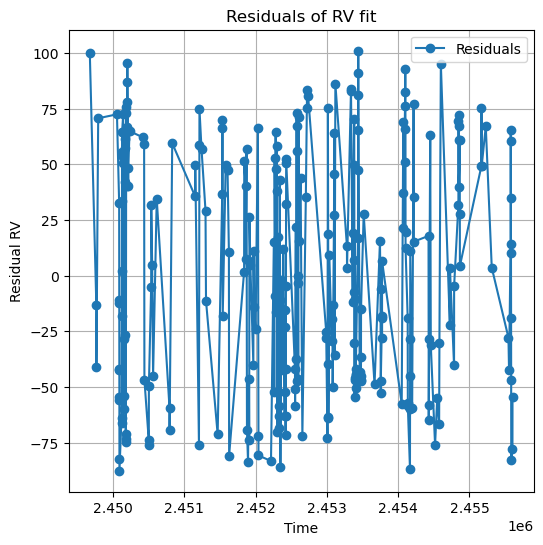

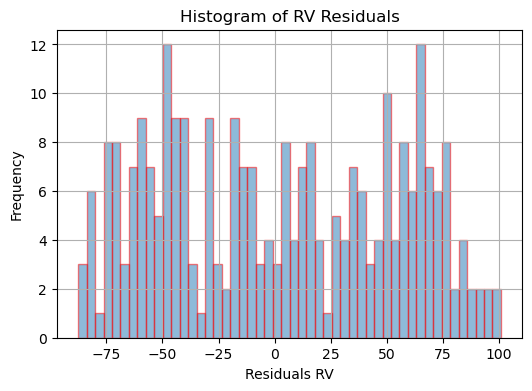

Standard deviation of residuals: 52.21 m/s


In [9]:
residuals = rv - y_fit
#plotting pt.3
plt.figure(figsize=(6,6))
plt.plot(time, residuals,'o-',label="Residuals")
plt.xlabel("Time")
plt.ylabel("Residual RV")
plt.title("Residuals of RV fit")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(6,4))
plt.hist(residuals,bins=50,edgecolor="red",alpha=0.5)
plt.xlabel("Residuals RV")
plt.ylabel("Frequency")
plt.title("Histogram of RV Residuals")
plt.grid(True)
plt.savefig("residual_histogram.pdf")
plt.show()
#checking standard deviation and seeing if its correct
print(f"Standard deviation of residuals: {np.std(residuals):.2f} m/s") 

There was no need to use popt* here and instead we can use our y_fit and rv which made my residuals come out better

In [11]:
# planet mass now using the sin fit
K = abs(A_fit)
P = (2*np.pi) / B_fit  
print("RV Amplitude K =", K, "m/s")
print("Orbital Period P =", P, "days")
# Nasa Planet archive info
M_star = 0.95   
# Planet mass calculation :D
M_planet = (K / 28.4) * (P / 365)**(1/3) * (M_star)**(2/3)
print("Estimated Planet Mass =", M_planet, "Jupiter masses")

RV Amplitude K = 47.91772823938166 m/s
Orbital Period P = 4807.055566131899 days
Estimated Planet Mass = 3.850546534050396 Jupiter masses


What my original planet mass was assumed to be correct, because I got my first fitted curve incorrect the rest of my data would be a ton harder to do. by rewriting my code entirely I was able to simplify everything which got me my correct answer